In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = 'Data Curah Hujan Harian Cleaned.xlsx'
df = pd.read_excel(file_path, header=0)
print(df.head())

     Tanggal  Curah Hujan
0 2022-01-01         36.0
1 2022-01-02         59.4
2 2022-01-03          3.5
3 2022-01-04          1.7
4 2022-01-05         99.5


In [3]:
# Mengonversi kolom 'Tanggal' ke format datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')

In [4]:
# Memastikan kolom 'Curah Hujan' bertipe numerik
df['Curah Hujan'] = pd.to_numeric(df['Curah Hujan'], errors='coerce')

In [5]:
# Menyimpan 'Tanggal' sebagai kolom untuk referensi
df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

In [6]:
# Menetapkan kolom 'Tanggal' sebagai indeks
df.set_index('Tanggal', inplace=True)

In [9]:
# Menampilkan statistik bulanan
statistik_bulanan = df.resample('M').agg(
    Rata_Rata=('Curah Hujan', 'mean'),
    Std_Dev=('Curah Hujan', 'std'),
    Min=('Curah Hujan', 'min'),
    Q1=('Curah Hujan', lambda x: x.quantile(0.25)),  # Kuartil 25%
    Median=('Curah Hujan', lambda x: x.quantile(0.5)),  # Kuartil 50% (median)
    Q3=('Curah Hujan', lambda x: x.quantile(0.75)),  # Kuartil 75%
    Maksimal=('Curah Hujan', 'max')
)
# Menampilkan statistik bulanan
print(statistik_bulanan)

            Rata_Rata    Std_Dev  Min     Q1  Median      Q3  Maksimal
Tanggal                                                               
2022-01-31  18.477419  28.832548  0.0  0.900    4.60  25.650     117.0
2022-02-28  22.803571  30.214903  0.0  5.375   11.60  29.325     144.0
2022-03-31  12.722581  16.148678  0.0  1.950    7.70  13.250      76.5
2022-04-30   4.003333   7.220874  0.0  0.000    1.10   4.500      32.0
2022-05-31   5.780645   9.046930  0.0  0.000    0.70   8.150      32.5
2022-06-30  13.580000  20.766475  0.0  0.000    4.50  18.875      78.0
2022-07-31   7.096774   9.409126  0.0  1.750    4.10   8.250      40.5
2022-08-31   8.925806  14.855705  0.0  0.400    3.00  11.800      66.5
2022-09-30   6.743333   8.430024  0.0  1.100    4.40   9.350      40.5
2022-10-31  19.741935  16.305455  0.0  6.250   16.40  31.150      58.5
2022-11-30  18.406667  24.000746  0.0  1.725    5.40  33.575      89.6
2022-12-31  19.848387  25.045530  0.0  6.400   12.00  24.150     126.4
2023-0

C:\Users\muham\AppData\Local\Temp\ipykernel_5768\1084863292.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  statistik_bulanan = df.resample('M').agg(


In [10]:
# Memisahkan data berdasarkan tahun
df_2022 = df[df['Tahun'] == 2022]
df_2023 = df[df['Tahun'] == 2023]
df_2024 = df[df['Tahun'] == 2024]

C:\Users\muham\AppData\Local\Temp\ipykernel_5768\582302221.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2022, palette="Set2", width=0.6)
C:\Users\muham\AppData\Local\Temp\ipykernel_5768\582302221.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


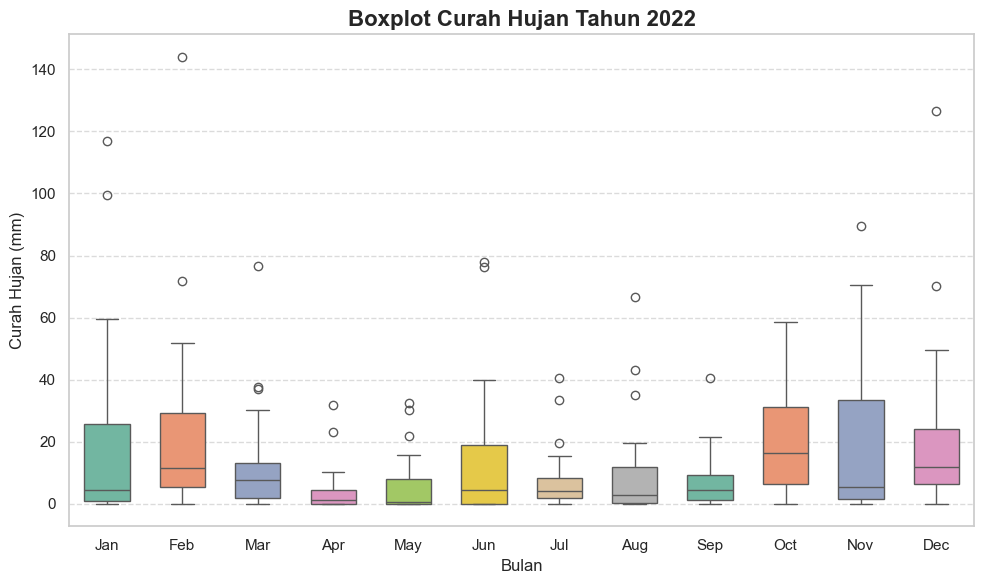

In [11]:
# Membuat boxplot untuk curah hujan tahun 2022, dengan pengelompokan berdasarkan bulan
plt.figure(figsize=(10, 6))  # Ukuran grafik
sns.set(style="whitegrid")  # Menggunakan grid latar belakang untuk memperjelas boxplot
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2022, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2022', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_5768\3152922871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2023, palette="Set2", width=0.6)
C:\Users\muham\AppData\Local\Temp\ipykernel_5768\3152922871.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


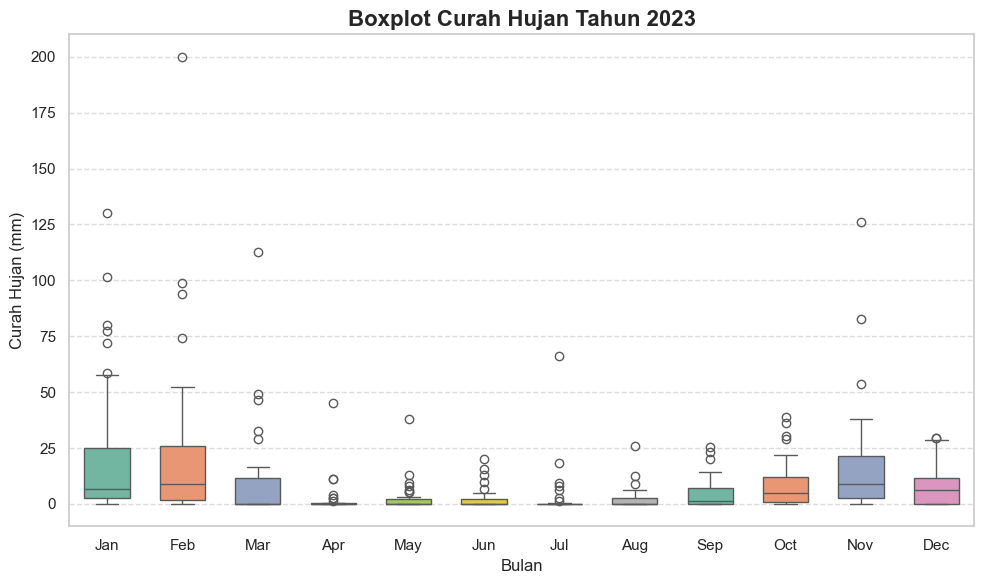

In [12]:
# Boxplot untuk tahun 2023
plt.figure(figsize=(10, 6))  # Ukuran grafik
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2023, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2023', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_5768\2342588967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2024, palette="Set2", width=0.6)
C:\Users\muham\AppData\Local\Temp\ipykernel_5768\2342588967.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])


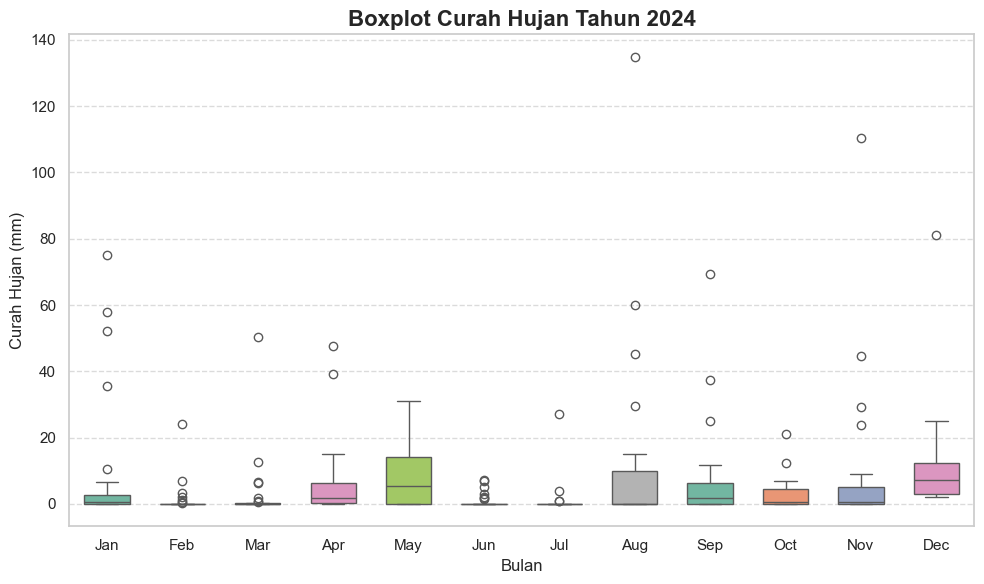

In [13]:
# Boxplot untuk tahun 2024
plt.figure(figsize=(10, 6))  # Ukuran grafik
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2024, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2024', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

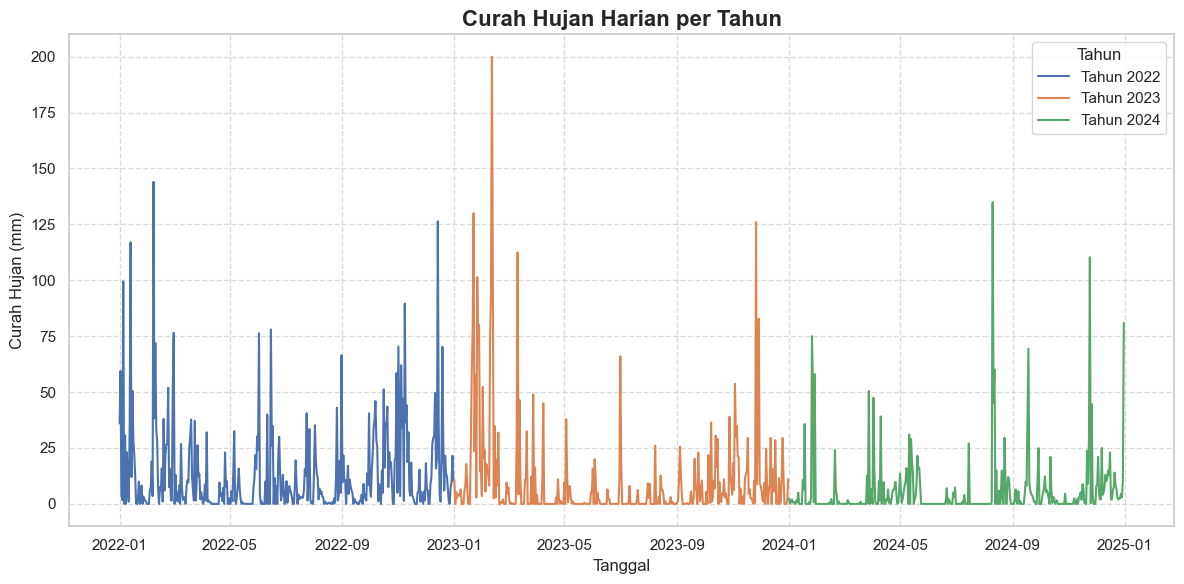

In [15]:
# Membaca data dari file Excel
file_path = 'Data Curah Hujan Harian Cleaned.xlsx'
df = pd.read_excel(file_path, header=0)

# Mengonversi kolom 'Tanggal' ke format datetime
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')

# Memastikan kolom 'Curah Hujan' bertipe numerik
df['Curah Hujan'] = pd.to_numeric(df['Curah Hujan'], errors='coerce')

# Menyimpan 'Tanggal' sebagai kolom untuk referensi
df['Tahun'] = df['Tanggal'].dt.year

# Memisahkan data berdasarkan tahun
data_per_tahun = {year: data for year, data in df.groupby('Tahun')}

# Membuat grafik linier untuk setiap tahun
plt.figure(figsize=(12, 6))
for year, data in data_per_tahun.items():
    plt.plot(data['Tanggal'], data['Curah Hujan'], label=f'Tahun {year}')

plt.title('Curah Hujan Harian per Tahun', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Data Curah Hujan Harian Cleaned.xlsx'
df = pd.read_excel(file_path, header=0)
print(df.head())

df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df['Curah Hujan'] = pd.to_numeric(df['Curah Hujan'], errors='coerce')

df['Tahun'] = df['Tanggal'].dt.year
df['Bulan'] = df['Tanggal'].dt.month

df.set_index('Tanggal', inplace=True)

statistik_bulanan = df.resample('M').agg(
    Rata_Rata=('Curah Hujan', 'mean'),
    Std_Dev=('Curah Hujan', 'std'),
    Min=('Curah Hujan', 'min'),
    Q1=('Curah Hujan', lambda x: x.quantile(0.25)),
    Median=('Curah Hujan', lambda x: x.quantile(0.5)),
    Q3=('Curah Hujan', lambda x: x.quantile(0.75)),
    Maksimal=('Curah Hujan', 'max')
)
print(statistik_bulanan)

In [ ]:
file_path = 'Data Curah Hujan Harian Cleaned.xlsx'
df = pd.read_excel(file_path, header=0)

df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df['Curah Hujan'] = pd.to_numeric(df['Curah Hujan'], errors='coerce')

df['Tahun'] = df['Tanggal'].dt.year

data_per_tahun = {year: data for year, data in df.groupby('Tahun')}

plt.figure(figsize=(12, 6))
for year, data in data_per_tahun.items():
    plt.plot(data['Tanggal'], data['Curah Hujan'], label=f'Tahun {year}')

plt.title('Curah Hujan Harian per Tahun', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'Data Curah Hujan Harian Cleaned.xlsx' 
df = pd.read_excel(file_path, header=0)
print(df.head())

df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')
df['Curah Hujan'] = pd.to_numeric(df['Curah Hujan'], errors='coerce')

df_2022 = df[df['Tahun'] == 2022]
df_2023 = df[df['Tahun'] == 2023]
df_2024 = df[df['Tahun'] == 2024]

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2022, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2022', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2023, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2023', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
ax = sns.boxplot(x='Bulan', y='Curah Hujan', data=df_2024, palette="Set2", width=0.6)
plt.title('Boxplot Curah Hujan Tahun 2024', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()